In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
import hipp
from skimage.transform import ThinPlateSplineTransform

In [3]:
raster_filepath = "/mnt/summer/USERS/DEHECQA/DIVERGENCE/data/KH9_PC/joined_images/D3C1203-200139A014.tif"
v_edges = hipp.kh9pc.collimation_lines.detect_vertical_edges(raster_filepath)

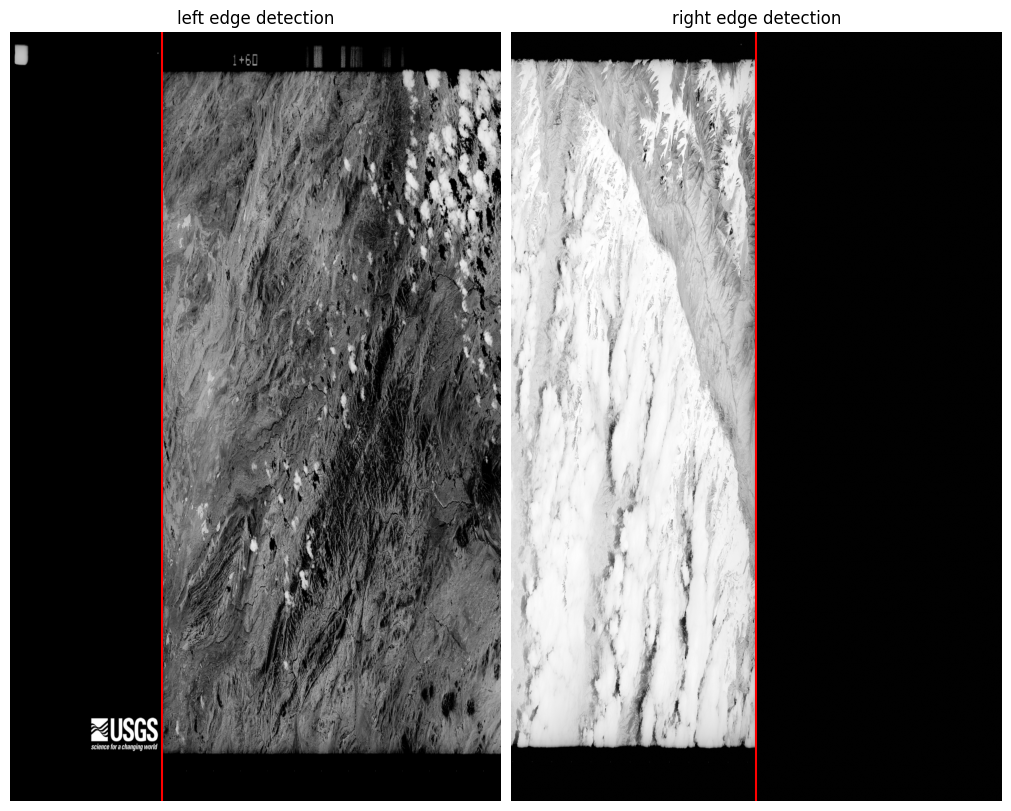

In [8]:
hipp.kh9pc.collimation_lines.plot_vertical_edges(raster_filepath, v_edges)

In [48]:
polys = hipp.kh9pc.collimation_lines.estimate_horizontal_poly(
    raster_filepath,
    v_edges,
    polynomial_degree=4,
    ransac_residual_threshold=80
)

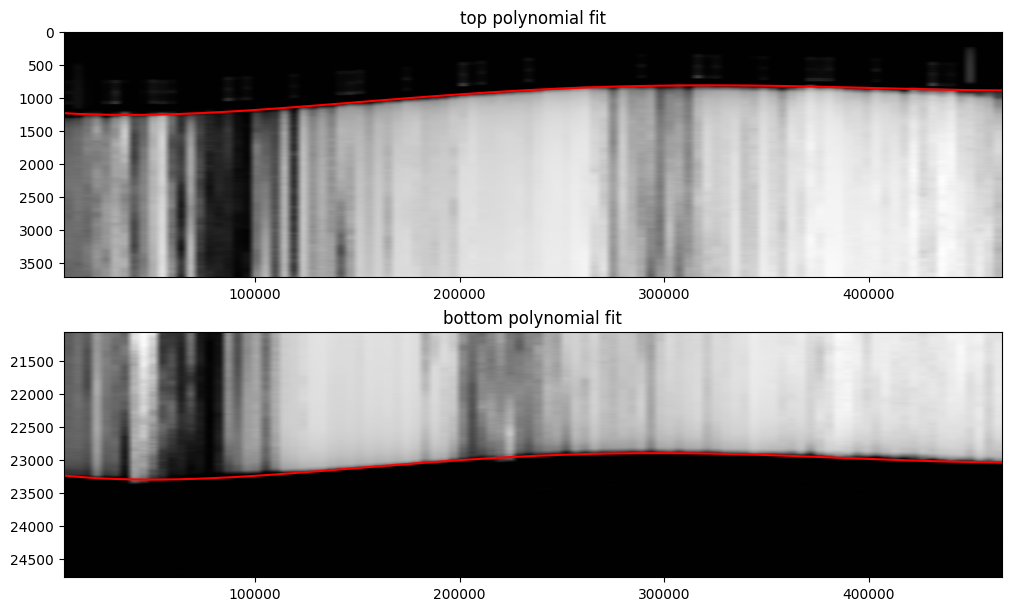

In [49]:
hipp.kh9pc.collimation_lines.plot_horizontal_poly(raster_filepath, polys, v_edges)

In [50]:
src_grid, dst_grid, output_size = hipp.kh9pc.collimation_lines.compute_source_and_target_grid_v2(
    v_edges, polys
)
src_points = src_grid.reshape(-1, 2)
dst_points = dst_grid.reshape(-1, 2)

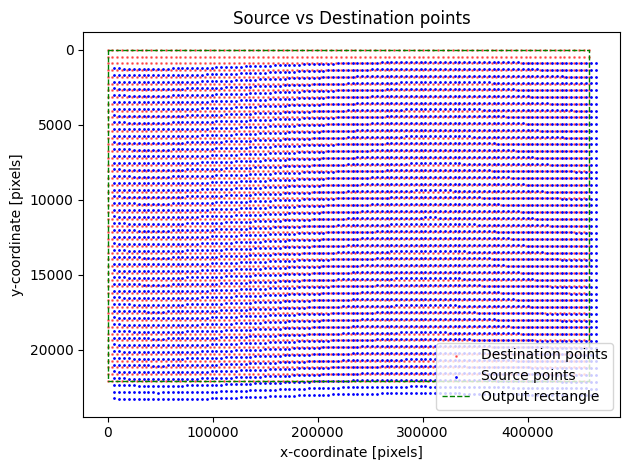

In [51]:
hipp.kh9pc.qc.plot_src_and_dst_points(src_points, dst_points, output_size)

In [ ]:
inverse_remap = ThinPlateSplineTransform()
inverse_remap.estimate(dst_points, src_points)

hipp.image.remap_tif_blockwise(
        raster_filepath,
        "/mnt/summer/USERS/DEHECQA/DIVERGENCE/data/KH9_PC/joined_images/D3C1203-200139A014_preproc.tif",
        inverse_remap,
        output_size,
        block_size=2**13,
        pbar_desc="remapping",
        lowres_step=100,
    )

/tmp/ipykernel_3240728/440861286.py:2: FutureWarning: `estimate` is deprecated since version 0.26 and will be removed in version 2.2. Please use `ThinPlateSplineTransform.from_estimate` class constructor instead.
  inverse_remap.estimate(dst_points, src_points)
remapping:  65%|████████████████████████████████████████████████████████████████████████████▌                                         | 109/168 [12:18<07:18,  7.43s/block]